# MOSAIC Demonstration: 2D Displacement Analysis

## Filter-Based Approach Linking Diffuse Scattering Features to Site-Resolved Real-Space Fields

This notebook demonstrates the core MOSAIC workflow using a **2D projected displacement** case
(PMN-like supercell projected along a pseudocubic axis).

**Workflow overview:**
1. Load an atomistic configuration (`.f2d` structure file)
2. Compute scattering amplitude via type-3 NUFFT
3. Visualise the full diffuse scattering intensity with a semi-transparent mask overlay
4. Apply a butterfly-shaped reciprocal-space mask and invert to obtain site-resolved displacement fields
5. Compare unfiltered vs. filtered displacement maps

The method applies a Fourier filter to the scattering amplitude over reciprocal-space regions
encompassing specific diffuse features, yielding atomically-resolved maps of displacements
responsible for those features.

In [2]:
import sys, os, json, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sympy as sp

# Ensure MOSAIC project root is on the path
MOSAIC_ROOT = Path(os.path.abspath("")).parent  # adjust if needed
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

# Enable saving of intermediate scattering interval artifacts (.hdf5, with legacy .npz support)
# These contain q_grid, q_amp, q_amp_av needed for intensity visualisation
os.environ["MOSAIC_SAVE_SCATTERING_INTERVAL_ARTIFACTS"] = "1"

# Force CPU NUFFT if no GPU is available (uncomment if needed)
# os.environ["MOSAIC_NUFFT_CPU_ONLY"] = "1"

# Configuration
EXAMPLE_DIR = Path("config_2D/displacement")
STRUCTURE_FILE = "sample_2d.f2d"

print(f"MOSAIC root : {MOSAIC_ROOT.name}")
print(f"Example dir : {EXAMPLE_DIR}")
print(f"Structure   : {STRUCTURE_FILE}")


MOSAIC root : MOSAIC
Example dir : config_2D/displacement
Structure   : sample_2d.f2d


## 1. Inspect the Structure File

The `.f2d` file contains a 2D projected supercell: supercell dimensions, cell parameters,
and atomic positions (actual and average) in fractional coordinates.

In [3]:
struct_path = EXAMPLE_DIR / STRUCTURE_FILE

with open(struct_path) as f:
    lines = f.readlines()

# Parse header
header = lines[0].strip().split("\t")
supercell_dims = [int(x) for x in header[1:]]
cell_line = lines[1].strip().split("\t")
cell_params = [float(x) for x in cell_line[1:]]

n_atoms = len(lines) - 3  # skip header, cell, column-header lines

print(f"Supercell dimensions : {supercell_dims}")
print(f"Cell (Ang/deg)       : {cell_params}")
print(f"Number of atoms      : {n_atoms}")
print(f"\nFirst 5 atom lines:")
for line in lines[3:8]:
    print(f"  {line.strip()}")

Supercell dimensions : [40, 40]
Cell (Ang/deg)       : [162.08548, 162.08548, 90.0]
Number of atoms      : 1600

First 5 atom lines:
  El1	-1.5126E-4	-2.6577E-4	-2.44687E-6	4.44149E-6	1
  El1	-9.51381E-8	0.02496	-2.44687E-6	0.025	1
  El1	-1.72021E-4	0.05015	-2.44687E-6	0.05	1
  El1	-2.86357E-4	0.07519	-2.44687E-6	0.075	1
  El1	-5.21088E-4	0.10006	-2.44687E-6	0.1	1


## 2. Run MOSAIC: Unfiltered (All Reciprocal Space)

First we run MOSAIC with **no mask** (pass-all equation `h**2 >= -1`) to compute the full
scattering amplitude and extract unfiltered displacement fields. This uses the complete
reciprocal-space information and serves as the reference.

In [4]:
# --- Write config for UNMASKED run ---
# Pass-all mask: h**2>=-1 is always true (avoids sympy scalar simplification)
UNMASKED_CONFIG = {
    "schema_version": 2,
    "paths": {
        "config_root": str(EXAMPLE_DIR.resolve()),
        "structure_file": STRUCTURE_FILE,
        "output_directory": str((EXAMPLE_DIR / "output_demo_all").resolve()),
    },
    "structure": {
        "dimension": 2,
        "coefficients": {"scheme": "ones"},
    },
    "reciprocal_space": {
        "intervals": [{"limit": [40.0, 40.0], "subvolume_step": [5.0, 5.0]}],
        "mask": {"equation": "h**2 + k**2 + 1 >= 0"},
    },
    "processing": {
        "mode": "displacement",
        "method": "from_average",
        "num_chunks": 1,
        "fresh_start": True,
        "run_postprocessing": True,
        "decoder": {
            "source": "compute",
            "compute_output_directory": str(
                (EXAMPLE_DIR / "output_demo_all_decoder").resolve()
            ),
        },
        "points": [
            {
                "selector": {"element": "El1", "reference_number": 1},
                "window": {
                    "dist_from_atom_center": [0.8, 0.8],
                    "step_in_angstrom": [0.0125, 0.0125],
                },
            }
        ],
    },
    "runtime": {
        "progress": {"force": True, "task_logs": True},
        "dask": {
            "backend": "local",
            "max_workers": 4,
            "threads_per_worker": 1,
            "processes": True,
            "worker_wait_timeout": "30s",
        },
        "scattering_weights": {"kind": "ones", "calculator": "default"},
    },
}

# Write to file
unmasked_input_path = EXAMPLE_DIR / "input_parameters_demo_all.json"
with open(unmasked_input_path, "w") as f:
    json.dump(UNMASKED_CONFIG, f, indent=2)

# Write run_parameters pointing to the input config
unmasked_run_path = EXAMPLE_DIR / "run_parameters_demo_all.json"
with open(unmasked_run_path, "w") as f:
    json.dump({"input_parameters_path": str(unmasked_input_path.resolve())}, f, indent=2)

print(f"Unmasked config written to: {unmasked_input_path}")
print(f"Run parameters written to:  {unmasked_run_path}")

Unmasked config written to: config_2D/displacement/input_parameters_demo_all.json
Run parameters written to:  config_2D/displacement/run_parameters_demo_all.json


In [5]:
from example_runner import run_mosaic_case

# Run MOSAIC (unmasked) — computes scattering amplitude + displacement decoding
print("=" * 60)
print("Running MOSAIC — UNMASKED (all reciprocal space)")
print("=" * 60)
run_mosaic_case(unmasked_run_path, repo_root=MOSAIC_ROOT, tag='unmasked')


Running MOSAIC — UNMASKED (all reciprocal space)
Running MOSAIC -- UNMASKED
  run file: <repo>/examples/config_2D/displacement/run_parameters_demo_all.json


2026-07-31 16:31:56,218 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-31 16:31:56,218 - [INFO] - app - (main.py:84) - Using input parameters: config_2D/displacement/input_parameters_demo_all.json
2026-07-31 16:31:56,218 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_2D/displacement
2026-07-31 16:31:56,218 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True


2026-07-31 16:31:58,287 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-31 16:31:58,287 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-31 16:31:58,287 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) - average_structure.cell_ids missing; not filtering by cell box.
2026-07-31 16:31:58,295 - [INFO] - core.patch_centers.from_average - (from_average.py:440) - Point data appended/updated in output_demo_all/processed_point_data/point_data.hdf5
2026-07-31 16:31:58,319 - [INFO] - PointDataProcessor - (point_data.py:86) - grid_amplitude_initialized synced (1600 points).
2026-07-31 16:31:58,319 - [INFO] - PointDataProcessor - (point_data.py:101) - Found 1 unique chunk_ids.
2026-07-31 16:31:58,319 - [INFO] - PointDataProcessor - (point_data.py:113) - Processing chunk 0 with 1600 uninitialized points.


2026-07-31 16:31:59,889 - [INFO] - PointDataProcessor - (point_data.py:278) - Chunk 0: Amplitudes saved to point_data_chunk_0_amplitudes.hdf5
2026-07-31 16:31:59,890 - [INFO] - PointDataProcessor - (point_data.py:522) - Updated grid_amplitude_initialized saved to output_demo_all/processed_point_data/point_data.hdf5
2026-07-31 16:31:59,928 - [INFO] - ReciprocalSpaceIntervalGenerator - (interval_generator.py:143) - Generated 256 reciprocal_space intervals.
2026-07-31 16:31:59,947 - [INFO] - ReciprocalSpaceIntervalManager - (manager.py:119) - reciprocal_space intervals saved to output_demo_all/processed_point_data/point_reciprocal_space_data.hdf5


2026-07-31 16:32:01,855 - [INFO] - core.scattering.planning - (planning.py:639) - qspace q-normalization: 256 intervals | total mask_rejected=0 | multiplicities={1: 256} (per-interval detail at DEBUG)


...

2026-07-31 16:32:21,639 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_all/processed_point_data/residual_chunk_0_shapeNd.hdf5
2026-07-31 16:32:21,648 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_all/processed_point_data/residual_chunk_0_amplitudes_ntotal_reciprocal_space_points.hdf5


2026-07-31 16:32:24,301 - [INFO] - core.residual_field.execution - (execution.py:2560) - Residual-field finished – 8 tasks submitted


2026-07-31 16:32:24,539 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:32:24,541 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:32:24,542 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:397) - Decoder source provenance saved to 'output_demo_all_decoder/processed_point_data/decoder_source_provenance.json'.
2026-07-31 16:32:24,543 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:32:24,548 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:325) - Deco

2026-07-31 16:32:33,211 - [INFO] - core.runtime.dask_client - (dask_client.py:278) - Dask client closed.


[unmasked] completed OK


## 3. Diffuse Scattering Intensity with Mask Overlay

**Note:** At this stage the mask is **not** applied to the data — the full (unmasked)
scattering amplitude has already been computed. We only overlay the mask on the
intensity plots to show which reciprocal-space regions will be selected in the next step.

The scattering amplitudes are defined as follows:

- **Total amplitude**: $A_{\mathrm{tot}}(\mathbf{Q})$ — computed via type-3 NUFFT from all atomic positions.
- **Average structure contribution**: $\langle A(\mathbf{Q})\rangle \cdot \psi(\mathbf{Q})$, where
  $\langle A(\mathbf{Q})\rangle = \sum_m \bar{f}_m(\mathbf{Q})\,e^{i\mathbf{Q}\cdot\bar{\mathbf{r}}_m}$
  is the coherent average amplitude and
  $\psi(\mathbf{Q}) = \sum_{n=1}^{N} e^{i\mathbf{Q}\cdot\mathbf{R}_n}$
  is the interference (lattice shape) function of the supercell.
- **Diffuse scattering amplitude**: $\Delta A(\mathbf{Q}) = A_{\mathrm{tot}}(\mathbf{Q}) - \langle A(\mathbf{Q})\rangle \cdot \psi(\mathbf{Q})$

The **diffuse scattering intensity** is then $I_{\mathrm{DS}}(\mathbf{Q}) = |\Delta A(\mathbf{Q})|^2$,
capturing contributions from local disorder after removing the Bragg (average-structure) part.

The butterfly-shaped mask selects anisotropic diffuse wings around Bragg reflections —
these are the features associated with correlated atomic displacements.

This full (unmasked) run also computes the **M-decoder** matrix, which is reused by
the subsequent masked runs (it depends only on the reciprocal-space grid geometry,
not on the mask).

In [6]:
# --- Helper: load all interval HDF5/NPZ artifacts and stitch into a single intensity map ---

def load_interval_file(path):
    if path.suffix == ".hdf5":
        import h5py
        with h5py.File(path, "r") as h5:
            return h5["q_grid"][:], h5["q_amp"][:], h5["q_amp_av"][:]
    with np.load(path) as data:
        return data["q_grid"], data["q_amp"], data["q_amp_av"]


def load_interval_data(output_dir):
    """Load q_grid, q_amp, q_amp_av from interval HDF5 artifacts, with legacy NPZ fallback."""
    interval_dir = Path(output_dir) / "processed_point_data" / "precomputed_intervals"
    hdf5_files = sorted(interval_dir.glob("interval_*.hdf5"))
    npz_files = sorted(interval_dir.glob("interval_*.npz"))
    interval_files = hdf5_files if hdf5_files else npz_files
    if not interval_files:
        raise FileNotFoundError(
            f"No interval_*.hdf5 or interval_*.npz files found in {interval_dir}"
        )

    all_q_grid, all_q_amp, all_q_amp_av = [], [], []
    for interval_path in interval_files:
        q_grid_i, q_amp_i, q_amp_av_i = load_interval_file(interval_path)
        all_q_grid.append(q_grid_i)
        all_q_amp.append(q_amp_i)
        all_q_amp_av.append(q_amp_av_i)

    return (
        np.concatenate(all_q_grid, axis=0),
        np.concatenate(all_q_amp, axis=0),
        np.concatenate(all_q_amp_av, axis=0),
    )


def unique_sorted_tol(a, tol=1e-10):
    """Unique sorted values, merging near-equals."""
    s = np.sort(np.asarray(a, dtype=float))
    if s.size == 0:
        return s
    out = [s[0]]
    for v in s[1:]:
        if abs(v - out[-1]) > tol:
            out.append(v)
    return np.array(out)


def nearest_index(vec, vals):
    """For each vals[i], return index of nearest vec[j]."""
    vec, vals = np.asarray(vec, float), np.asarray(vals, float)
    j = np.searchsorted(vec, vals)
    j0 = np.clip(j - 1, 0, vec.size - 1)
    j1 = np.clip(j, 0, vec.size - 1)
    d0, d1 = np.abs(vals - vec[j0]), np.abs(vals - vec[j1])
    return np.where(d1 < d0, j1, j0)


def build_intensity_grid(q_grid, intensity, cell_param, supercell_dim):
    """Convert q_grid (internal units) to hkl and reshape into a 2D grid."""
    # Convert from internal 2*pi/cell units to hkl
    Q_hkl = cell_param * q_grid / (supercell_dim * 2 * np.pi)
    h, k = Q_hkl[:, 0], Q_hkl[:, 1]

    hv = unique_sorted_tol(h)
    kv = unique_sorted_tol(k)
    Nh, Nk = hv.size, kv.size

    ih = nearest_index(hv, h)
    ik = nearest_index(kv, k)

    I2 = np.full((Nk, Nh), np.nan)
    I2[ik, ih] = intensity
    return hv, kv, I2


print("Helpers loaded.")

Helpers loaded.


In [7]:
# --- Load unfiltered amplitudes and compute total intensity ---
CELL_PARAM = cell_params[0]    # e.g. 162.085480 Ang
SC_DIM = supercell_dims[0]     # e.g. 40

unmasked_output = EXAMPLE_DIR / "output_demo_all"
q_grid, q_amp, q_amp_av = load_interval_data(unmasked_output)

# Total intensity: |A_tot(Q)|^2
intensity_total = (q_amp * np.conj(q_amp)).real

# Diffuse intensity: |A_tot(Q) - <A(Q)>|^2
intensity_diffuse = ((q_amp - q_amp_av) * np.conj(q_amp - q_amp_av)).real

# Build 2D grids
hv, kv, I_total_2d = build_intensity_grid(q_grid, intensity_total, CELL_PARAM, SC_DIM)
_, _, I_diffuse_2d = build_intensity_grid(q_grid, intensity_diffuse, CELL_PARAM, SC_DIM)

print(f"Q-grid shape   : {q_grid.shape}")
print(f"Intensity grid : ({len(kv)}, {len(hv)})")
print(f"h range        : [{hv.min():.1f}, {hv.max():.1f}]")
print(f"k range        : [{kv.min():.1f}, {kv.max():.1f}]")

Q-grid shape   : (10246401, 2)
Intensity grid : (3201, 3201)
h range        : [-40.0, 40.0]
k range        : [-40.0, 40.0]


In [8]:
# --- Generate the butterfly mask on the same hkl grid ---

def make_butterfly_mask_grid(hv, kv,
                              width=0.5, gamma=1.5, decay=3.0, suppression=0.50,
                              env_floor=0.02):
    """Build a boolean mask on the (kv x hv) grid using the hyperbolic butterfly equation."""
    hh, kk = np.meshgrid(hv, kv)  # shape (Nk, Nh)

    u2 = np.sin(np.pi * (hh - kk)) ** 2
    v2 = np.sin(np.pi * (hh + kk)) ** 2
    envelope = np.exp(-decay * (np.sin(np.pi * hh) ** 2 + np.sin(np.pi * kk) ** 2))
    r2 = hh ** 2 + kk ** 2 + 1e-6

    align_u = (hh + kk) ** 2 / (2 * r2)
    align_v = (hh - kk) ** 2 / (2 * r2)

    f_u = 1.0 - suppression * align_u
    f_v = 1.0 - suppression * align_v

    gate_env = (envelope >= env_floor).astype(float)

    t_u = width * envelope * f_u * np.where(f_u > 0, 1.0, 0.0) * gate_env
    t_v = width * envelope * f_v * np.where(f_v > 0, 1.0, 0.0) * gate_env

    mask = (u2 * (v2 + gamma) < t_u) | (v2 * (u2 + gamma) < t_v)
    return mask


butterfly_mask = make_butterfly_mask_grid(hv, kv)
n_masked = butterfly_mask.sum()
n_total = butterfly_mask.size
print(f"Mask coverage: {n_masked}/{n_total} points ({100*n_masked/n_total:.1f}%)")

Mask coverage: 1469377/10246401 points (14.3%)


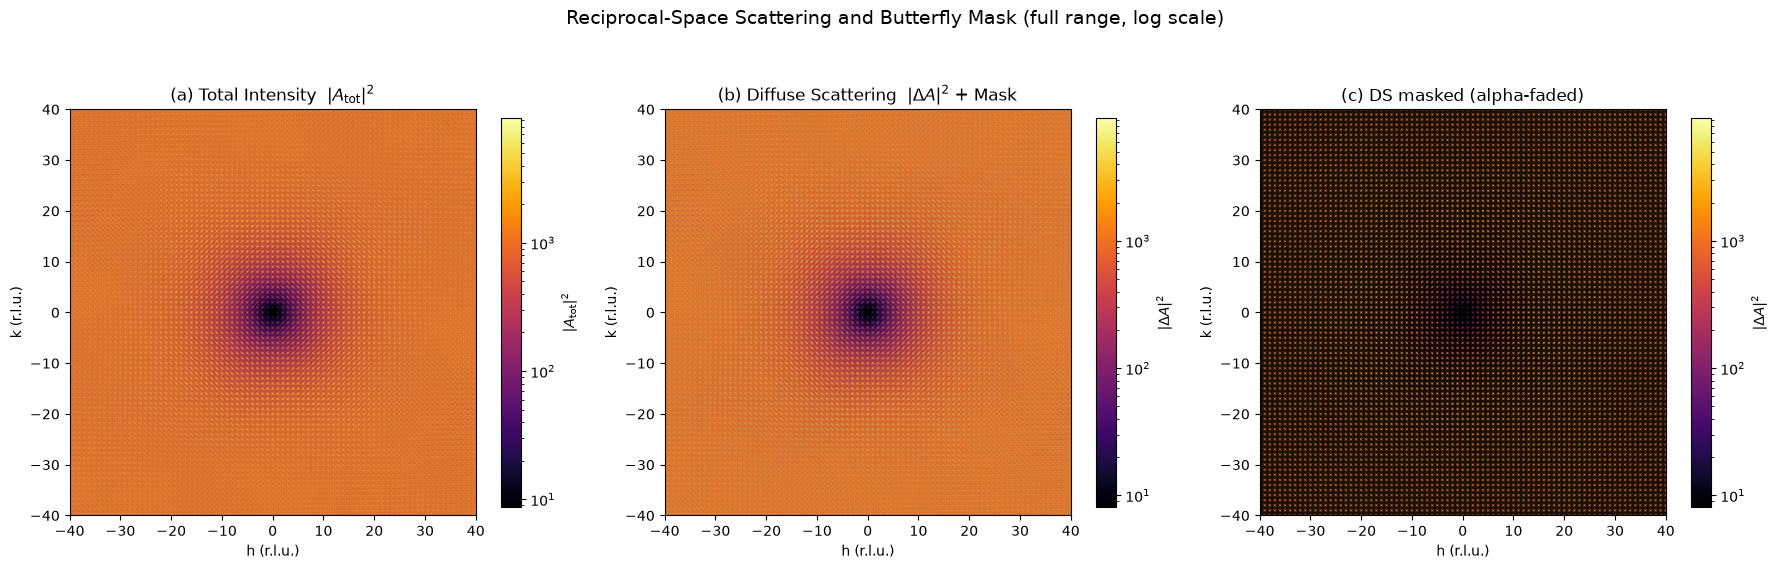

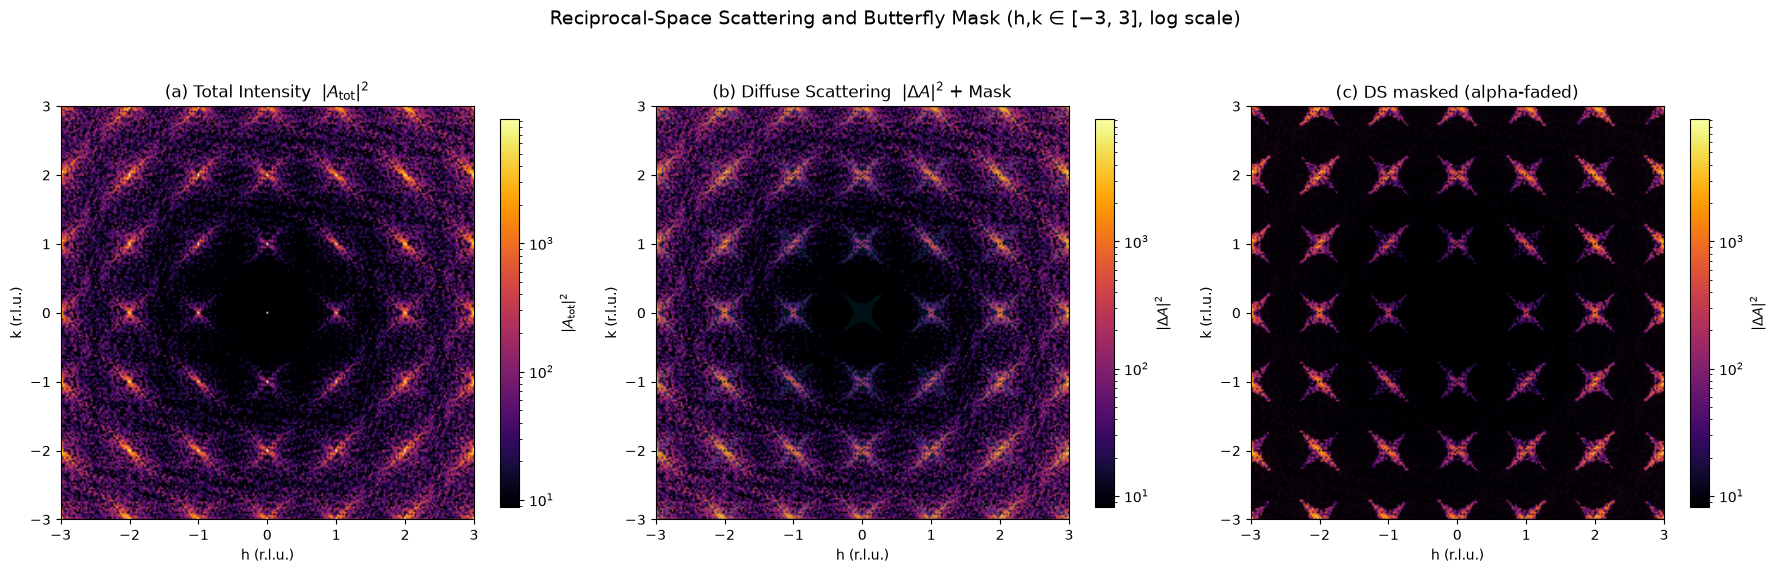

In [9]:
# --- Plot: Scattering + Semi-Transparent Butterfly Mask Overlay (log scale) ---
from matplotlib.colors import LogNorm

# Clip zeros for log scale
I_total_log = np.where(I_total_2d > 0, I_total_2d, np.nan)
I_diffuse_log = np.where(I_diffuse_2d > 0, I_diffuse_2d, np.nan)

# Percentile-based colour limits for good contrast
vmin_tot = np.nanpercentile(I_total_log, 1)
vmax_tot = np.nanpercentile(I_total_log, 99.5)
vmin_ds = np.nanpercentile(I_diffuse_log, 1)
vmax_ds = np.nanpercentile(I_diffuse_log, 99.5)

extent = [hv.min(), hv.max(), kv.min(), kv.max()]

# --- Full range ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Total scattering intensity
ax = axes[0]
im0 = ax.imshow(I_total_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
fig.colorbar(im0, ax=ax, shrink=0.8, label="$|A_{\\mathrm{tot}}|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(a) Total Intensity  $|A_{\\mathrm{tot}}|^2$")

# (b) Diffuse scattering + mask overlay
ax = axes[1]
im1 = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))

# Overlay mask — very transparent (alpha=0.08)
mask_rgba = np.zeros((*butterfly_mask.shape, 4))
mask_rgba[butterfly_mask, :] = [0.0, 0.9, 1.0, 0.08]
ax.imshow(mask_rgba, origin="lower", extent=extent, aspect="equal", interpolation="nearest")

fig.colorbar(im1, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(b) Diffuse Scattering  $|\\Delta A|^2$ + Mask")

# (c) Diffuse intensity with alpha modulation (faded outside mask)
ax = axes[2]
im2 = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
alpha_grid = np.where(butterfly_mask, 1.0, 0.12)
im2.set_alpha(alpha_grid)
fig.colorbar(im2, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(c) DS masked (alpha-faded)")
ax.set_facecolor("black")

fig.suptitle("Reciprocal-Space Scattering and Butterfly Mask (full range, log scale)",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# --- Zoomed view: hkl from -3 to 3 ---
HKL_LIM = 3
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Total intensity zoomed
ax = axes2[0]
im = ax.imshow(I_total_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(a) Total Intensity  $|A_{\\mathrm{tot}}|^2$")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|A_{\\mathrm{tot}}|^2$")

# (b) Diffuse + mask zoomed
ax = axes2[1]
im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
ax.imshow(mask_rgba, origin="lower", extent=extent, aspect="equal", interpolation="nearest")
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(b) Diffuse Scattering  $|\\Delta A|^2$ + Mask")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")

# (c) DS alpha-faded zoomed
ax = axes2[2]
im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
im.set_alpha(alpha_grid)
ax.set_facecolor("black")
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(c) DS masked (alpha-faded)")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")

fig2.suptitle(
    f"Reciprocal-Space Scattering and Butterfly Mask (h,k ∈ [−{HKL_LIM}, {HKL_LIM}], log scale)",
    fontsize=14, y=1.02,
)
fig2.tight_layout()
plt.show()

## 4. Zoomed Views: Mask around Bragg Reflections

The butterfly-shaped diffuse features are most prominent near Bragg positions. Here we
zoom in on a few key reflections to show the mask geometry.

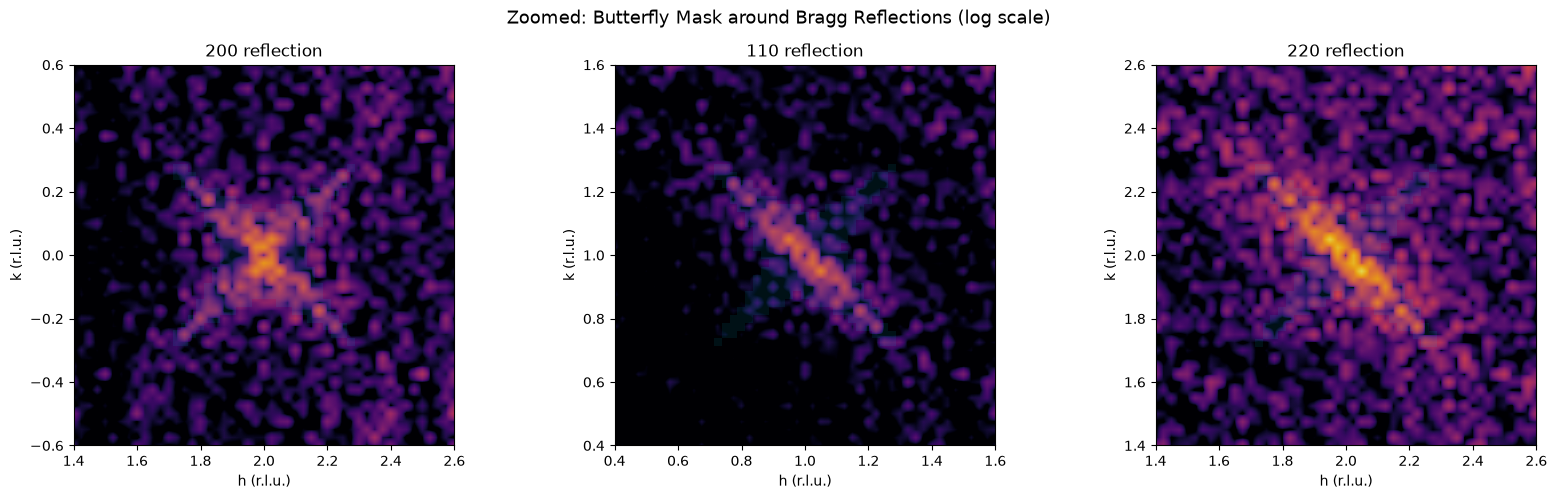

In [10]:
# --- Zoomed insets around specific Bragg reflections (log scale) ---

zooms = [
    {"center": (2, 0), "half": 0.6, "label": "200 reflection"},
    {"center": (1, 1), "half": 0.6, "label": "110 reflection"},
    {"center": (2, 2), "half": 0.6, "label": "220 reflection"},
]

fig, axes = plt.subplots(1, len(zooms), figsize=(5.5 * len(zooms), 5))
if len(zooms) == 1:
    axes = [axes]

for ax, z in zip(axes, zooms):
    cx, cy = z["center"]
    hw = z["half"]

    im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                   aspect="equal", interpolation="bilinear",
                   norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))

    # Mask overlay — very transparent
    mask_rgba_z = np.zeros((*butterfly_mask.shape, 4))
    mask_rgba_z[butterfly_mask, :] = [0.0, 0.9, 1.0, 0.08]
    ax.imshow(mask_rgba_z, origin="lower", extent=extent, aspect="equal",
              interpolation="nearest")

    ax.set_xlim(cx - hw, cx + hw)
    ax.set_ylim(cy - hw, cy + hw)
    ax.set_xlabel("h (r.l.u.)")
    ax.set_ylabel("k (r.l.u.)")
    ax.set_title(z["label"])

fig.suptitle("Zoomed: Butterfly Mask around Bragg Reflections (log scale)", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Run MOSAIC: Masked (Butterfly Wings Only)

Now we apply the butterfly-shaped mask to select only the diffuse wing features around
Bragg reflections and invert via the displacement-mode estimator to obtain site-resolved
displacement fields associated with those features.

The **M-decoder** matrix was already computed during the full (unmasked) run in Step 2.
Both masked runs below reuse that precomputed decoder (`source: "compute"` pointing to
the same decoder output directory), avoiding redundant recomputation.

In [11]:
# --- Butterfly mask equation (selects wing regions) ---
BUTTERFLY_MASK_EQ = (
    "(sin(pi*(h - k))**2 * (sin(pi*(h + k))**2 + 1.5) < "
    "(0.5 * exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) * "
    "(1.0 - 0.5 * ((h + k)**2 / (2 * (h**2 + k**2 + 1e-6)))) * "
    "Heaviside((1.0 - 0.5 * ((h + k)**2 / (2 * (h**2 + k**2 + 1e-6)))), 0.0) * "
    "Heaviside(exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) - 0.02, 0.0))) | "
    "(sin(pi*(h + k))**2 * (sin(pi*(h - k))**2 + 1.5) < "
    "(0.5 * exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) * "
    "(1.0 - 0.5 * ((h - k)**2 / (2 * (h**2 + k**2 + 1e-6)))) * "
    "Heaviside((1.0 - 0.5 * ((h - k)**2 / (2 * (h**2 + k**2 + 1e-6)))), 0.0) * "
    "Heaviside(exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) - 0.02, 0.0)))"
)

# --- Complementary mask (everything EXCEPT the wings) ---
REST_MASK_EQ = (
    "~((sin(pi*(h - k))**2 * (sin(pi*(h + k))**2 + 1.5) < "
    "(0.5 * exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) * "
    "(1.0 - 0.5 * ((h + k)**2 / (2 * (h**2 + k**2 + 1e-6)))) * "
    "Heaviside((1.0 - 0.5 * ((h + k)**2 / (2 * (h**2 + k**2 + 1e-6)))), 0.0) * "
    "Heaviside(exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) - 0.02, 0.0))) | "
    "(sin(pi*(h + k))**2 * (sin(pi*(h - k))**2 + 1.5) < "
    "(0.5 * exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) * "
    "(1.0 - 0.5 * ((h - k)**2 / (2 * (h**2 + k**2 + 1e-6)))) * "
    "Heaviside((1.0 - 0.5 * ((h - k)**2 / (2 * (h**2 + k**2 + 1e-6)))), 0.0) * "
    "Heaviside(exp(-3.0 * (sin(pi*h)**2 + sin(pi*k)**2)) - 0.02, 0.0))))"
)

# Decoder output directory from the full (unmasked) run — reused by masked runs
FULL_DECODER_DIR = str((EXAMPLE_DIR / "output_demo_all_decoder").resolve())


def write_mosaic_config(tag, mask_equation, decoder_output_dir=None):
    """Write a MOSAIC config for a demo run.

    tag: short label, e.g. "masked" or "rest".
         Output directory  : output_demo_{tag}
         Input config file  : input_parameters_demo_{tag}.json
         Run parameters file: run_parameters_demo_{tag}.json
    """
    output_dir_name = f"output_demo_{tag}"
    if decoder_output_dir is None:
        decoder_output_dir = str((EXAMPLE_DIR / f"{output_dir_name}_decoder").resolve())

    config = {
        "schema_version": 2,
        "paths": {
            "config_root": str(EXAMPLE_DIR.resolve()),
            "structure_file": STRUCTURE_FILE,
            "output_directory": str((EXAMPLE_DIR / output_dir_name).resolve()),
        },
        "structure": {
            "dimension": 2,
            "coefficients": {"scheme": "ones"},
        },
        "reciprocal_space": {
            "intervals": [{"limit": [40.0, 40.0], "subvolume_step": [5.0, 5.0]}],
            "mask": {"equation": mask_equation},
        },
        "processing": {
            "mode": "displacement",
            "method": "from_average",
            "num_chunks": 1,
            "fresh_start": True,
            "run_postprocessing": True,
            "decoder": {
                "source": "compute",
                "compute_output_directory": decoder_output_dir,
            },
            "points": [
                {
                    "selector": {"element": "El1", "reference_number": 1},
                    "window": {
                        "dist_from_atom_center": [0.8, 0.8],
                        "step_in_angstrom": [0.0125, 0.0125],
                    },
                }
            ],
        },
        "runtime": {
            "progress": {"force": True, "task_logs": True},
            "dask": {
                "backend": "local",
                "max_workers": 4,
                "threads_per_worker": 1,
                "processes": True,
                "worker_wait_timeout": "30s",
            },
            "scattering_weights": {"kind": "ones", "calculator": "default"},
        },
    }

    input_path = EXAMPLE_DIR / f"input_parameters_demo_{tag}.json"
    run_path = EXAMPLE_DIR / f"run_parameters_demo_{tag}.json"

    with open(input_path, "w") as f:
        json.dump(config, f, indent=2)
    with open(run_path, "w") as f:
        json.dump({"input_parameters_path": str(input_path.resolve())}, f, indent=2)

    return run_path


# Write configs — both masked runs reuse the M-decoder from the full run
masked_run_path = write_mosaic_config("masked", BUTTERFLY_MASK_EQ,
                                       decoder_output_dir=FULL_DECODER_DIR)
rest_run_path = write_mosaic_config("rest", REST_MASK_EQ,
                                     decoder_output_dir=FULL_DECODER_DIR)

print(f"Masked run config:        {masked_run_path}")
print(f"Complementary run config: {rest_run_path}")
print(f"Both reuse M-decoder from: {EXAMPLE_DIR / 'output_demo_all_decoder'}")

Masked run config:        config_2D/displacement/run_parameters_demo_masked.json
Complementary run config: config_2D/displacement/run_parameters_demo_rest.json
Both reuse M-decoder from: config_2D/displacement/output_demo_all_decoder


In [12]:
# Fresh subprocess per case (shared launcher handles env + dask state)
from example_runner import run_mosaic_case

run_mosaic_case(masked_run_path, repo_root=MOSAIC_ROOT, tag="masked")


Running MOSAIC -- MASKED
  run file: <repo>/examples/config_2D/displacement/run_parameters_demo_masked.json


2026-07-31 16:33:15,026 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-31 16:33:15,026 - [INFO] - app - (main.py:84) - Using input parameters: config_2D/displacement/input_parameters_demo_masked.json
2026-07-31 16:33:15,026 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_2D/displacement
2026-07-31 16:33:15,026 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True


2026-07-31 16:33:17,012 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-31 16:33:17,012 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-31 16:33:17,013 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) - average_structure.cell_ids missing; not filtering by cell box.
2026-07-31 16:33:17,021 - [INFO] - core.patch_centers.from_average - (from_average.py:440) - Point data appended/updated in output_demo_masked/processed_point_data/point_data.hdf5
2026-07-31 16:33:17,079 - [INFO] - PointDataProcessor - (point_data.py:86) - grid_amplitude_initialized synced (1600 points).
2026-07-31 16:33:17,080 - [INFO] - PointDataProcessor - (point_data.py:101) - Found 1 unique chunk_ids.
2026-07-31 16:33:17,080 - [INFO] - PointDataProcessor - (point_data.py:113) - Processing chunk 0 with 1600 uninitialized points.


2026-07-31 16:33:18,704 - [INFO] - PointDataProcessor - (point_data.py:278) - Chunk 0: Amplitudes saved to point_data_chunk_0_amplitudes.hdf5
2026-07-31 16:33:18,706 - [INFO] - PointDataProcessor - (point_data.py:522) - Updated grid_amplitude_initialized saved to output_demo_masked/processed_point_data/point_data.hdf5
2026-07-31 16:33:18,728 - [INFO] - ReciprocalSpaceIntervalGenerator - (interval_generator.py:143) - Generated 256 reciprocal_space intervals.
2026-07-31 16:33:18,748 - [INFO] - ReciprocalSpaceIntervalManager - (manager.py:119) - reciprocal_space intervals saved to output_demo_masked/processed_point_data/point_reciprocal_space_data.hdf5


2026-07-31 16:33:23,416 - [INFO] - core.scattering.planning - (planning.py:639) - qspace q-normalization: 256 intervals | total mask_rejected=8777024 | multiplicities={1: 256} (per-interval detail at DEBUG)


...

2026-07-31 16:33:40,900 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_masked/processed_point_data/residual_chunk_0_shapeNd.hdf5
2026-07-31 16:33:40,909 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_masked/processed_point_data/residual_chunk_0_amplitudes_ntotal_reciprocal_space_points.hdf5


2026-07-31 16:33:43,549 - [INFO] - core.residual_field.execution - (execution.py:2560) - Residual-field finished – 8 tasks submitted


2026-07-31 16:33:43,789 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:33:43,791 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:33:43,792 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:397) - Decoder source provenance saved to 'output_demo_all_decoder/processed_point_data/decoder_source_provenance.json'.
2026-07-31 16:33:43,793 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:33:43,798 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:325) - Deco

2026-07-31 16:33:52,342 - [INFO] - core.runtime.dask_client - (dask_client.py:278) - Dask client closed.


[masked] completed OK


In [13]:
# Run MOSAIC — COMPLEMENTARY (everything except butterfly wings)
print("=" * 60)
print("Running MOSAIC — COMPLEMENTARY (rest of reciprocal space)")
print("=" * 60)
run_mosaic_case(rest_run_path, repo_root=MOSAIC_ROOT, tag='rest')


Running MOSAIC — COMPLEMENTARY (rest of reciprocal space)
Running MOSAIC -- REST
  run file: <repo>/examples/config_2D/displacement/run_parameters_demo_rest.json


2026-07-31 16:33:54,668 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-31 16:33:54,669 - [INFO] - app - (main.py:84) - Using input parameters: config_2D/displacement/input_parameters_demo_rest.json
2026-07-31 16:33:54,669 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_2D/displacement
2026-07-31 16:33:54,669 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True


2026-07-31 16:33:56,504 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-31 16:33:56,505 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-31 16:33:56,506 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) - average_structure.cell_ids missing; not filtering by cell box.
2026-07-31 16:33:56,521 - [INFO] - core.patch_centers.from_average - (from_average.py:440) - Point data appended/updated in output_demo_rest/processed_point_data/point_data.hdf5
2026-07-31 16:33:56,550 - [INFO] - PointDataProcessor - (point_data.py:86) - grid_amplitude_initialized synced (1600 points).
2026-07-31 16:33:56,550 - [INFO] - PointDataProcessor - (point_data.py:101) - Found 1 unique chunk_ids.
2026-07-31 16:33:56,551 - [INFO] - PointDataProcessor - (point_data.py:113) - Processing chunk 0 with 1600 uninitialized points.


2026-07-31 16:33:58,209 - [INFO] - PointDataProcessor - (point_data.py:278) - Chunk 0: Amplitudes saved to point_data_chunk_0_amplitudes.hdf5
2026-07-31 16:33:58,210 - [INFO] - PointDataProcessor - (point_data.py:522) - Updated grid_amplitude_initialized saved to output_demo_rest/processed_point_data/point_data.hdf5
2026-07-31 16:33:58,232 - [INFO] - ReciprocalSpaceIntervalGenerator - (interval_generator.py:143) - Generated 256 reciprocal_space intervals.
2026-07-31 16:33:58,250 - [INFO] - ReciprocalSpaceIntervalManager - (manager.py:119) - reciprocal_space intervals saved to output_demo_rest/processed_point_data/point_reciprocal_space_data.hdf5


2026-07-31 16:34:03,334 - [INFO] - core.scattering.planning - (planning.py:639) - qspace q-normalization: 256 intervals | total mask_rejected=1469377 | multiplicities={1: 256} (per-interval detail at DEBUG)


...

2026-07-31 16:34:24,325 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_rest/processed_point_data/residual_chunk_0_shapeNd.hdf5
2026-07-31 16:34:24,336 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:187) - File not found: output_demo_rest/processed_point_data/residual_chunk_0_amplitudes_ntotal_reciprocal_space_points.hdf5


2026-07-31 16:34:27,221 - [INFO] - core.residual_field.execution - (execution.py:2560) - Residual-field finished – 8 tasks submitted


2026-07-31 16:34:27,462 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:34:27,463 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:34:27,472 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:397) - Decoder source provenance saved to 'output_demo_all_decoder/processed_point_data/decoder_source_provenance.json'.
2026-07-31 16:34:27,473 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:291) - Loaded decoder M from 'output_demo_all_decoder/processed_point_data/decoder_M_97c6aaab0ab235df.npz' (shape (2, 16641), feature_dim=16641).
2026-07-31 16:34:27,480 - [INFO] - core.decoding.decoder_training - (decoder_cache.py:325) - Deco

2026-07-31 16:34:35,217 - [INFO] - core.runtime.dask_client - (dask_client.py:278) - Dask client closed.


[rest] completed OK


## 6. Load and Compare Displacement Fields

We now load the decoded displacement fields from all three MOSAIC runs:
- **Unfiltered**: all reciprocal space — the full displacement field
- **Masked** (butterfly wings): displacements associated with the anisotropic diffuse features
- **Complementary** (rest): displacements from non-wing regions (mostly noise)

The displacement-mode estimator extracts atom-resolved displacement vectors $\mathbf{u}_s$
by finding the peak of the real-space field $R_F(\mathbf{r})$ evaluated on a fine grid
around each average atomic position.

In [14]:
import csv
import h5py


def load_displacements(output_dir, chunk_id=0):
    """Load site-resolved displacements from a MOSAIC output directory."""
    proc_dir = Path(output_dir) / "processed_point_data"

    # Try new naming convention first, then old
    for pattern in [
        f"chunk_{chunk_id}_site_displacements.csv",
        f"output_chunk_{chunk_id}_first_moment_displacements.csv",
    ]:
        csv_path = proc_dir / pattern
        if csv_path.exists():
            break
    else:
        raise FileNotFoundError(
            f"No displacement CSV found in {proc_dir}. "
            f"Available files: {list(proc_dir.glob('*'))}"
        )

    ids, ux, uy = [], [], []
    with open(csv_path) as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            ids.append(int(row["central_point_id"]))
            ux.append(float(row["ux"]))
            uy.append(float(row["uy"]))

    ids = np.array(ids, dtype=int)
    order = np.argsort(ids)
    return ids[order], np.array(ux, dtype=float)[order], np.array(uy, dtype=float)[order]


def load_average_positions(output_dir):
    """Load average atom positions from point_data.hdf5."""
    h5_path = Path(output_dir) / "processed_point_data" / "point_data.hdf5"
    with h5py.File(h5_path, "r") as f:
        if "coordinates" not in f:
            raise KeyError(f"coordinates dataset missing from {h5_path}")
        return np.array(f["coordinates"])


# Load displacements from all three runs
ids_all, ux_all, uy_all = load_displacements(EXAMPLE_DIR / "output_demo_all")
ids_mask, ux_mask, uy_mask = load_displacements(EXAMPLE_DIR / "output_demo_masked")
ids_rest, ux_rest, uy_rest = load_displacements(EXAMPLE_DIR / "output_demo_rest")

print(f"Loaded {len(ids_all)} atom displacements from each run")
print(f"  Unfiltered  RMS |u|: {np.sqrt(np.mean(ux_all**2 + uy_all**2)):.4f} Ang")
print(f"  Masked      RMS |u|: {np.sqrt(np.mean(ux_mask**2 + uy_mask**2)):.4f} Ang")
print(f"  Complement  RMS |u|: {np.sqrt(np.mean(ux_rest**2 + uy_rest**2)):.4f} Ang")

Loaded 1600 atom displacements from each run
  Unfiltered  RMS |u|: 0.0730 Ang
  Masked      RMS |u|: 0.0534 Ang
  Complement  RMS |u|: 0.0490 Ang


## 7. Displacement Vector Maps

We visualise the displacement fields as quiver plots on the 2D projected supercell lattice. Vectors are keyed by `central_point_id`, plotted at `point_data.hdf5/coordinates`, with `ux` on x and `uy` on y.
- **(a)** Unfiltered displacement field (all reciprocal space) — contains all correlations
- **(b)** Butterfly-filtered displacement field — smooth, correlated domains become visible
- **(c)** Complementary (rest) — uncorrelated noise background

The filtered map reveals the nanometre-scale polar correlation textures previously
obscured by noise in the raw displacement field.

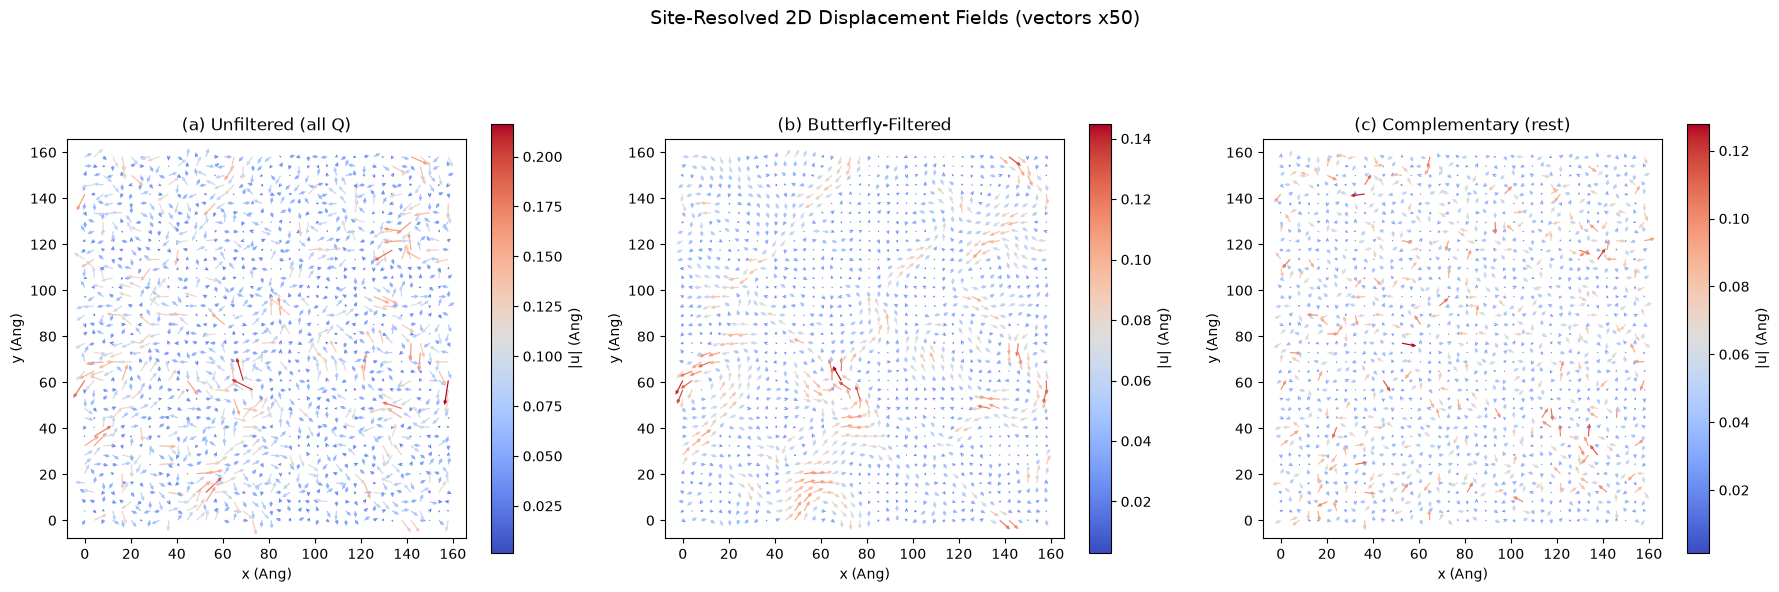

In [15]:
# --- Build atom positions from the same point_data.hdf5 order used by MOSAIC ---
# Do not synthesize these with default np.meshgrid: sample_2d.f2d / point_data.hdf5
# are ordered with y varying fastest for each x, while default meshgrid ravel is x-fast.
# The displacement CSV is keyed by central_point_id, so plot coordinates must be keyed
# the same way instead of assuming a row-major synthetic grid.
def positions_for_ids(output_dir, ids):
    coordinates = load_average_positions(output_dir)
    ids = np.asarray(ids, dtype=int)
    if ids.size == 0:
        return np.array([]), np.array([])
    if coordinates.ndim != 2 or coordinates.shape[1] < 2:
        raise ValueError(f"point_data coordinates must be (N, >=2), got {coordinates.shape}")
    if ids.min() < 0 or ids.max() >= coordinates.shape[0]:
        raise IndexError(
            f"central_point_id range [{ids.min()}, {ids.max()}] is outside coordinate table "
            f"with {coordinates.shape[0]} rows"
        )
    ordered = coordinates[ids, :2]
    return ordered[:, 0], ordered[:, 1]

assert np.array_equal(ids_all, ids_mask), "masked IDs differ from unmasked IDs"
assert np.array_equal(ids_all, ids_rest), "rest IDs differ from unmasked IDs"
x_pos, y_pos = positions_for_ids(EXAMPLE_DIR / "output_demo_all", ids_all)

SCALE = 50  # vector scale for visibility

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (ux_all, uy_all, "(a) Unfiltered (all Q)"),
    (ux_mask, uy_mask, "(b) Butterfly-Filtered"),
    (ux_rest, uy_rest, "(c) Complementary (rest)"),
]

for ax, (ux, uy, title) in zip(axes, datasets):
    umag = np.sqrt(ux**2 + uy**2)

    q = ax.quiver(
        x_pos, y_pos,
        ux * SCALE, uy * SCALE,
        umag,
        cmap="coolwarm",
        scale=1, scale_units="xy",
        angles="xy",
        width=0.003,
        headwidth=3,
        headlength=3,
    )
    ax.set_aspect("equal")
    ax.set_xlabel("x (Ang)")
    ax.set_ylabel("y (Ang)")
    ax.set_title(title)
    fig.colorbar(q, ax=ax, shrink=0.8, label="|u| (Ang)")

fig.suptitle(
    f"Site-Resolved 2D Displacement Fields (vectors x{SCALE})",
    fontsize=14, y=1.02,
)
fig.tight_layout()
plt.show()


## 8. Linearity Check: $\mathbf{u}_{\text{mask}} + \mathbf{u}_{\text{rest}} \approx \mathbf{u}_{\text{all}}$

A key property of the MOSAIC framework is **strict linearity**: the displacement field
reconstructed from the full reciprocal space equals the sum of fields reconstructed from
any partition of that space. We verify this by computing the residual:

$$\Delta\mathbf{u} = (\mathbf{u}_{\text{mask}} + \mathbf{u}_{\text{rest}}) - \mathbf{u}_{\text{all}}$$

This should be negligible compared to the displacement magnitudes.

RMS |u_all|      : 0.073011 Ang
RMS residual     : 1.19e-08 Ang
Relative error   : 1.64e-07


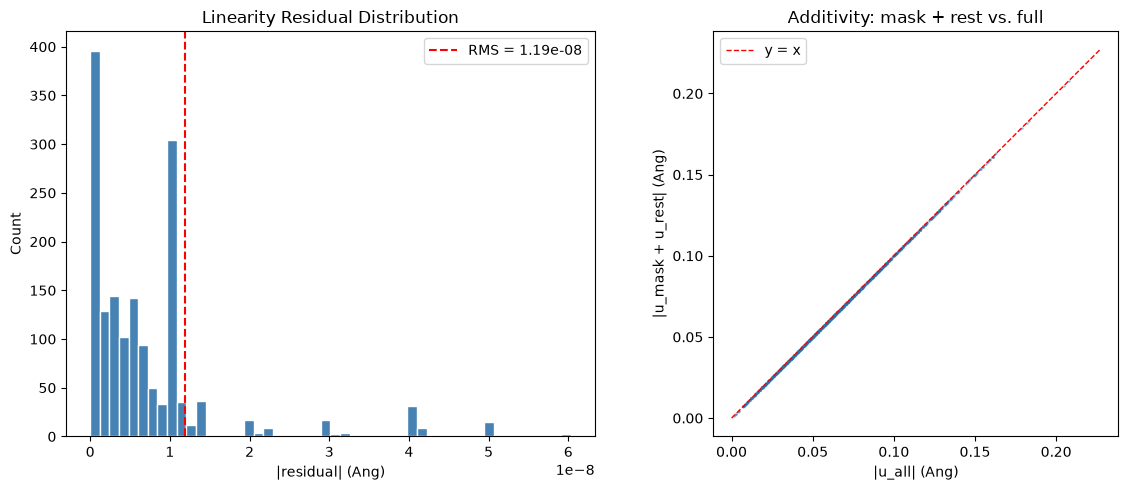

In [16]:
# Linearity check
dx = (ux_mask + ux_rest) - ux_all
dy = (uy_mask + uy_rest) - uy_all
residual_mag = np.sqrt(dx**2 + dy**2)
full_mag = np.sqrt(ux_all**2 + uy_all**2)

rms_residual = np.sqrt(np.mean(residual_mag**2))
rms_full = np.sqrt(np.mean(full_mag**2))

print(f"RMS |u_all|      : {rms_full:.6f} Ang")
print(f"RMS residual     : {rms_residual:.2e} Ang")
print(f"Relative error   : {rms_residual / rms_full:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of residual magnitudes
ax = axes[0]
ax.hist(residual_mag, bins=50, color="steelblue", edgecolor="white")
ax.axvline(rms_residual, color="red", ls="--", label=f"RMS = {rms_residual:.2e}")
ax.set_xlabel("|residual| (Ang)")
ax.set_ylabel("Count")
ax.set_title("Linearity Residual Distribution")
ax.legend()

# Scatter: |u_mask + u_rest| vs |u_all|
ax = axes[1]
sum_mag = np.sqrt((ux_mask + ux_rest)**2 + (uy_mask + uy_rest)**2)
ax.scatter(full_mag, sum_mag, s=1, alpha=0.3)
lims = [0, max(full_mag.max(), sum_mag.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlabel("|u_all| (Ang)")
ax.set_ylabel("|u_mask + u_rest| (Ang)")
ax.set_title("Additivity: mask + rest vs. full")
ax.set_aspect("equal")
ax.legend()

fig.tight_layout()
plt.show()

## 9. Summary

This notebook demonstrated the complete MOSAIC workflow for 2D displacement analysis:

1. **Structure loading** — a PMN-like 2D projected supercell (40 x 40 unit cells)
2. **Scattering amplitude computation** — forward type-3 NUFFT from atomic coordinates to reciprocal space
3. **Intensity visualisation** — total and diffuse scattering patterns with butterfly mask overlay
4. **Masked inverse transform** — butterfly-shaped mask isolates the anisotropic diffuse wings
5. **Displacement decoding** — site-resolved vector fields extracted via the M-decoder
6. **Linearity verification** — $\mathbf{u}_{\text{mask}} + \mathbf{u}_{\text{rest}} = \mathbf{u}_{\text{all}}$

The butterfly-filtered displacement map reveals smooth, correlated displacement domains
that are invisible in the unfiltered (noisy) field — demonstrating that MOSAIC can
link specific diffuse scattering features to their real-space structural origin.

In [16]:
# --- Cleanup: remove generated config files (optional) ---
# Uncomment below to remove demo output directories after inspection
# for d in ["output_demo_all", "output_demo_masked", "output_demo_rest",
#           "output_demo_all_decoder", "output_demo_masked_decoder", "output_demo_rest_decoder"]:
#     p = EXAMPLE_DIR / d
#     if p.exists():
#         shutil.rmtree(p)
#         print(f"Removed {p}")